In [13]:
!pip install pyspark

from pyspark import SparkContext

# Reset Spark (important for speed)
try:
    sc.stop()
except:
    pass

sc = SparkContext()

In [14]:
file_path = "small.txt"   # 🔥 FIRST RUN THIS

lines = sc.textFile(file_path)

edges = lines.map(lambda x: tuple(map(int, x.strip().split()))).distinct()

# Build adjacency list
links = edges.groupByKey().mapValues(list).cache()

n = links.count()
print("Total nodes:", n)

Total nodes: 100


In [15]:
ranks = links.map(lambda x: (x[0], 1.0 / n)).cache()

In [ ]:
beta = 0.8
iterations = 40

links_dict = dict(links.collect())   

ranks_dict = {node: 1.0/n for node in links_dict}

for _ in range(iterations):
    new_ranks = {node: (1 - beta)/n for node in links_dict}

    for node in links_dict:
        neighbors = links_dict[node]
        share = ranks_dict[node] / len(neighbors)

        for dest in neighbors:
            new_ranks[dest] += beta * share

    ranks_dict = new_ranks

In [19]:
sorted_ranks = sorted(ranks_dict.items(), key=lambda x: x[1], reverse=True)

print("Top 5:")
for i in sorted_ranks[:5]:
    print(i)

print("\nBottom 5:")
for i in sorted_ranks[-5:]:
    print(i)

Top 5:
(53, 0.0357312022326716)
(14, 0.03417090697259136)
(40, 0.03363008718974387)
(1, 0.030005979479788617)
(27, 0.02972014420140538)

Bottom 5:
(89, 0.003922466019802268)
(37, 0.0038082042916114506)
(81, 0.003695351749360991)
(59, 0.003669860660127284)
(85, 0.003409694077402821)


In [20]:
file_path = "whole.txt"

lines = sc.textFile(file_path)

edges = lines.map(lambda x: tuple(map(int, x.strip().split()))).distinct()

links = edges.groupByKey().mapValues(list)

n = links.count()
print("Total nodes:", n)

Total nodes: 1000


In [ ]:
beta = 0.8
iterations = 40

links_dict = dict(links.collect())   

ranks_dict = {node: 1.0/n for node in links_dict}

for _ in range(iterations):
    new_ranks = {node: (1 - beta)/n for node in links_dict}

    for node in links_dict:
        neighbors = links_dict[node]
        share = ranks_dict[node] / len(neighbors)

        for dest in neighbors:
            new_ranks[dest] += beta * share

    ranks_dict = new_ranks

In [22]:
sorted_ranks = sorted(ranks_dict.items(), key=lambda x: x[1], reverse=True)

print("Top 5:")
for i in sorted_ranks[:5]:
    print(i)

print("\nBottom 5:")
for i in sorted_ranks[-5:]:
    print(i)

Top 5:
(263, 0.002020291181518219)
(537, 0.0019433415714531503)
(965, 0.0019254478071662631)
(243, 0.0018526340162417312)
(285, 0.0018273721700645144)

Bottom 5:
(408, 0.00038779848719291705)
(424, 0.0003548153864930145)
(62, 0.0003531481051059628)
(93, 0.00035135689375165774)
(558, 0.0003286018525215297)


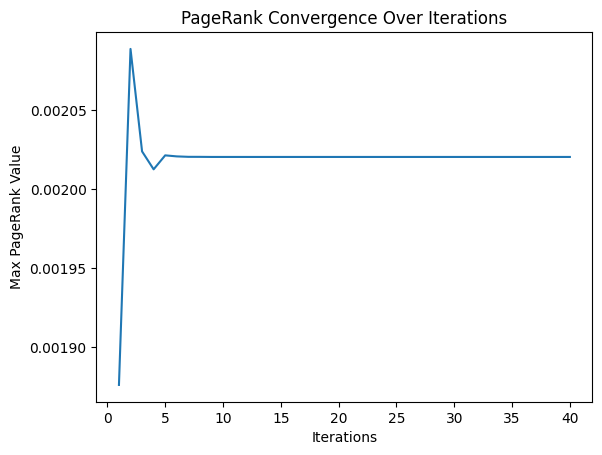

In [26]:
import matplotlib.pyplot as plt

beta = 0.8
iterations = 40

links_dict = dict(links.collect())

ranks_dict = {node: 1.0/n for node in links_dict}

# Track one node (or max value)
history = []

for _ in range(iterations):
    new_ranks = {node: (1 - beta)/n for node in links_dict}

    for node in links_dict:
        neighbors = links_dict[node]
        share = ranks_dict[node] / len(neighbors)

        for dest in neighbors:
            new_ranks[dest] += beta * share

    ranks_dict = new_ranks

    # Track max rank each iteration
    history.append(max(ranks_dict.values()))

# Plot graph
plt.figure()
plt.plot(range(1, iterations+1), history)
plt.xlabel("Iterations")
plt.ylabel("Max PageRank Value")
plt.title("PageRank Convergence Over Iterations")
plt.show()